<a href="https://colab.research.google.com/github/Dhanshree010/pattern-recognition-practical/blob/main/practical_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ================================
# Email Spam Detection using Naive Bayes
# ================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv("emails.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

# -------------------------------
# Data Preprocessing
# -------------------------------




First 5 Rows:
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]

Dataset Shape: (5172, 3002)


In [4]:
# Convert all columns except Email No. to numeric
for col in df.columns:
    if col != "Email No.":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Replace missing values with 0
df.fillna(0, inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\nMissing Values:", df.isnull().sum().sum())


Missing Values: 0


In [5]:
X = df.drop(columns=["Email No.", "Prediction"])
y = df["Prediction"].astype(int)

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -------------------------------
# Train Naive Bayes Model
# -------------------------------
model = MultinomialNB()

model.fit(X_train, y_train)

# -------------------------------
# Prediction
# -------------------------------
y_pred = model.predict(X_test)





Accuracy: 94.20%

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       735
           1       0.87      0.94      0.90       300

    accuracy                           0.94      1035
   macro avg       0.92      0.94      0.93      1035
weighted avg       0.94      0.94      0.94      1035



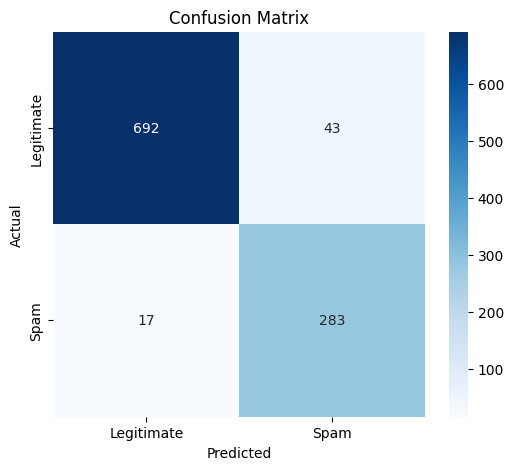

In [6]:
# -------------------------------
# Accuracy
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy: {:.2f}%".format(accuracy*100))

# -------------------------------
# Classification Report
# -------------------------------
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Spam"],
    yticklabels=["Legitimate","Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

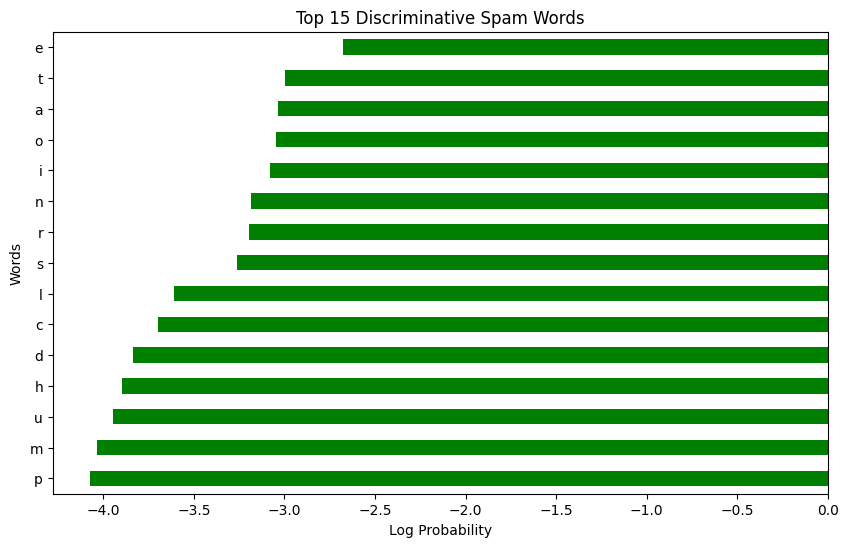


Top 15 Spam Words:
e   -2.675945
t   -2.996482
a   -3.033843
o   -3.049385
i   -3.078519
n   -3.184146
r   -3.196304
s   -3.263380
l   -3.610781
c   -3.697056
d   -3.834176
h   -3.897244
u   -3.943920
m   -4.035359
p   -4.075385
dtype: float64

Sample Predictions:
   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          1
5       1          1
6       0          0
7       0          0
8       0          0
9       1          1


In [7]:
spam_words = pd.Series(
    model.feature_log_prob_[1],
    index=X.columns
)

top_spam = spam_words.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_spam.sort_values().plot(
    kind="barh",
    color="green"
)

plt.title("Top 15 Discriminative Spam Words")
plt.xlabel("Log Probability")
plt.ylabel("Words")
plt.show()

print("\nTop 15 Spam Words:")
print(top_spam)

# -------------------------------
# Sample Predictions
# -------------------------------
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nSample Predictions:")
print(result.head(10))